In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import matplotlib.pyplot as plt


In [2]:
mithril_df_rRNA = pd.read_csv(
    "../rAPOGEE/data/mithril_V053.txt",
    sep="\t", low_memory=False, index_col="Mithril_id", na_values="."
)
mithril_df_rRNA = mithril_df_rRNA.loc[mithril_df_rRNA["Molecule_type"]=="rRNA"]
mithril_df_rRNA = mithril_df_rRNA.loc[:,~(mithril_df_rRNA.isna().all())]
mithril_df_rRNA["gene"] = mithril_df_rRNA.Gene_symbol.str.replace("-", "")
mithril_df_rRNA["Gene_position"] = mithril_df_rRNA["Gene_position"].astype(int)


################################# FIX #################################
# fix for the missing base in mithril variants collection.
# we remove the affected variants from mithril and adjust the Gene_position according to this change

ghost_positions = mithril_df_rRNA.loc[mithril_df_rRNA.Ref=="N", ["gene", "Gene_position"]]
display(ghost_positions)
for ghost_id, ghost in ghost_positions.drop_duplicates().iterrows(): # it's just one position
    mithril_df_rRNA.loc[(mithril_df_rRNA.gene==ghost.gene) & (mithril_df_rRNA.Gene_position>ghost.Gene_position), "Gene_position"] -= 1
mithril_df_rRNA.drop(ghost_positions.index, axis=0, inplace=True)
del ghost_id, ghost, ghost_positions

mithril_df_rRNA

,gene,Gene_position
Mithril_id,,
MITHRIL.9318,MTRNR2,1437
MITHRIL.9319,MTRNR2,1437
MITHRIL.9320,MTRNR2,1437
MITHRIL.9321,MTRNR2,1437


,Chr,Start,Ref,Alt,Molecule_type,Gene_symbol,Extended_annotation,Gene_position,Gene_start,Gene_end,...,Gnomad_AC_hom,Gnomad_AC_het,Gnomad_AF_hom,Gnomad_AF_het,Gnomad_filter,GenBank_freq,hpl-cnt-tot-frq,homoplasmy,heteroplasmy,gene
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1941,chrM,648,A,C,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,1,648,1601,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MTRNR1
MITHRIL.1942,chrM,648,A,G,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,1,648,1601,...,3.0,0.0,0.000053,0.0,PASS,0.000082,L2a-1-1033-0.1|L4b-1-91-1.1|U7a-2-315-0.63,NaN,NaN,MTRNR1
MITHRIL.1943,chrM,648,A,T,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,1,648,1601,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MTRNR1
MITHRIL.1944,chrM,649,A,C,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,2,648,1601,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MTRNR1
MITHRIL.1945,chrM,649,A,G,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,2,648,1601,...,0.0,0.0,0.000000,0.0,npg,NaN,NaN,NaN,NaN,MTRNR1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.9683,chrM,3228,T,C,rRNA,MT-RNR2,mitochondrially encoded 16S rRNA,1557,1671,3229,...,0.0,0.0,0.000000,0.0,npg,NaN,NaN,NaN,NaN,MTRNR2
MITHRIL.9684,chrM,3228,T,G,rRNA,MT-RNR2,mitochondrially encoded 16S rRNA,1557,1671,3229,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MTRNR2
MITHRIL.9685,chrM,3229,T,A,rRNA,MT-RNR2,mitochondrially encoded 16S rRNA,1558,1671,3229,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MTRNR2


In [3]:
rapogee_scores = pd.read_csv("../rAPOGEE/checkpoints/rAPOGEE_predictions.csv", sep="\t", index_col="Mithril_id")
rapogee_scores

,Start,Ref,Alt,Gene_symbol,Gene_position,rAPOGEE_score,rAPOGEE_quantile,rAPOGEE_oob,rAPOGEE_posterior,category
Mithril_id,,,,,,,,,,
MITHRIL.1941,648,A,C,MT-RNR1,1,0.262367,0.18,0.262367,3.686973e-07,benign
MITHRIL.1942,648,A,G,MT-RNR1,1,0.213403,0.10,0.212121,1.252327e-08,benign
MITHRIL.1943,648,A,T,MT-RNR1,1,0.239221,0.14,0.239221,8.477167e-08,benign
MITHRIL.1944,649,A,C,MT-RNR1,2,0.343674,0.36,0.343674,2.726607e-05,benign
MITHRIL.1945,649,A,G,MT-RNR1,2,0.351951,0.38,0.351951,3.986997e-05,benign
...,...,...,...,...,...,...,...,...,...,...
MITHRIL.9683,3228,T,C,MT-RNR2,1558,0.266290,0.18,0.266290,4.669735e-07,benign
MITHRIL.9684,3228,T,G,MT-RNR2,1558,0.302205,0.26,0.302205,3.505524e-06,benign
MITHRIL.9685,3229,T,A,MT-RNR2,1559,0.455647,0.60,0.455647,2.478844e-03,likely benign


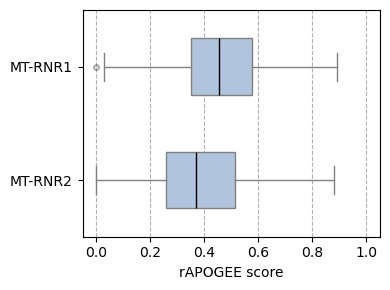

In [18]:


# Get unique genes sorted (optional for consistency)
genes = rapogee_scores.groupby("Gene_symbol").rAPOGEE_oob.median().sort_values(ascending=True).index
n_genes = len(genes)

# Set up figure
plt.figure(figsize=(4, 2+1))  # Adjust width based on number of genes

# Plot all boxplots in a single call (faster and cleaner)
data = [rapogee_scores.loc[mithril_df_rRNA[mithril_df_rRNA.Gene_symbol == gene].index, "rAPOGEE_oob"] for gene in genes]

plt.boxplot(
    data, positions=range(n_genes), patch_artist=True, vert=False, widths=.5,
    boxprops=dict(facecolor="lightsteelblue", color="gray"),
    medianprops=dict(color="black"),
    whiskerprops=dict(color="gray"),
    capprops=dict(color="gray"),
    flierprops=dict(markerfacecolor='gray', marker='o', markersize=4, linestyle='none', alpha=0.3)
)

# Format axes
plt.yticks(range(n_genes), genes)
plt.xlabel("rAPOGEE score")
plt.xlim(-.05,1.05)
plt.grid(axis="x", ls="--")
plt.tight_layout()
plt.savefig("./svg/rAPOGEE_genes_box.svg", bbox_inches='tight')
plt.show()

In [5]:
mithril_df_tRNA = pd.read_csv(
    "../tAPOGEE/data/mithril_V03.txt",
    sep="\t", low_memory=False, index_col="Mithril_id", na_values="."
)
mithril_df_tRNA = mithril_df_tRNA.loc[mithril_df_tRNA["class"]=="tRNA"]
mithril_df_tRNA = mithril_df_tRNA.loc[:,~(mithril_df_tRNA.isna().all())]
mithril_df_tRNA["aa"] =\
    mithril_df_tRNA["extended.annotation"].str.split("-").str[-1].str.split(" ").str[0].str.strip()\
    + mithril_df_tRNA["extended.annotation"].str.split(")", expand=True)[1].str.strip()

# following step is made in order to replicate the mtdb nomenclature:
# - invert Leu1 with Leu2
# - invert Ser1 with Ser2
mithril_df_tRNA["aa"] = mithril_df_tRNA.aa.str.replace("2","0").str.replace("1","2").str.replace("0","1")
mithril_df_tRNA["gene.position"] = mithril_df_tRNA["gene.position"].astype(int)

mithril_df_tRNA.drop(['MITHRIL.17488', 'MITHRIL.17489', 'MITHRIL.17490'], axis=0, inplace=True)

mithril_df_tRNA

,Start,Ref,Alt,class,Gene_symbol,extended.annotation,gene.position,gene.start,gene.end,gene.strand,...,54KJPN_AF,54KJPN_AN,AN_gnomad,AC_hom_gnomad,AC_het_gnomad,AF_hom_gnomad,AF_het_gnomad,FILTER_gnomad,freq_GenBank,aa
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,577,G,A,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),1,577,647,+,...,NaN,NaN,56433.0,0.0,0.0,0.000000,0.0,npg,NaN,Phe
MITHRIL.1729,577,G,C,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),1,577,647,+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Phe
MITHRIL.1730,577,G,T,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),1,577,647,+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Phe
MITHRIL.1731,578,T,A,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),2,577,647,+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Phe
MITHRIL.1732,578,T,C,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),2,577,647,+,...,NaN,NaN,56433.0,0.0,0.0,0.000000,0.0,npg,NaN,Phe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,16022,T,C,tRNA,MT-TP,TRNP; mitochondrially encoded tRNA-Pro (CCN),2,15956,16023,-,...,0.000018,54302.0,56431.0,1.0,0.0,0.000018,0.0,PASS,NaN,Pro
MITHRIL.48240,16022,T,G,tRNA,MT-TP,TRNP; mitochondrially encoded tRNA-Pro (CCN),2,15956,16023,-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pro
MITHRIL.48241,16023,G,A,tRNA,MT-TP,TRNP; mitochondrially encoded tRNA-Pro (CCN),1,15956,16023,-,...,NaN,NaN,56429.0,0.0,0.0,0.000000,0.0,npg,NaN,Pro


In [6]:
tapogee_scores = pd.read_csv("../tAPOGEE/checkpoints/tAPOGEE_predictions.csv", sep="\t", index_col="Mithril_id")
tapogee_scores

,Start,Ref,Alt,Gene_symbol,gene.position,tAPOGEE_score,tAPOGEE_oob_score,tAPOGEE_posterior,category
Mithril_id,,,,,,,,,
MITHRIL.1728,577,G,A,MT-TF,1,0.780641,0.780641,0.994751,pathogenic
MITHRIL.1729,577,G,C,MT-TF,1,0.703568,0.703568,0.951709,likely pathogenic
MITHRIL.1730,577,G,T,MT-TF,1,0.767472,0.767472,0.991911,pathogenic
MITHRIL.1731,578,T,A,MT-TF,2,0.520965,0.520965,0.320783,VUS
MITHRIL.1732,578,T,C,MT-TF,2,0.632326,0.632326,0.791225,VUS
...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,16022,T,C,MT-TP,2,0.665709,0.665709,0.887440,VUS
MITHRIL.48240,16022,T,G,MT-TP,2,0.773280,0.773280,0.993295,pathogenic
MITHRIL.48241,16023,G,A,MT-TP,1,0.841406,0.834604,0.999351,pathogenic


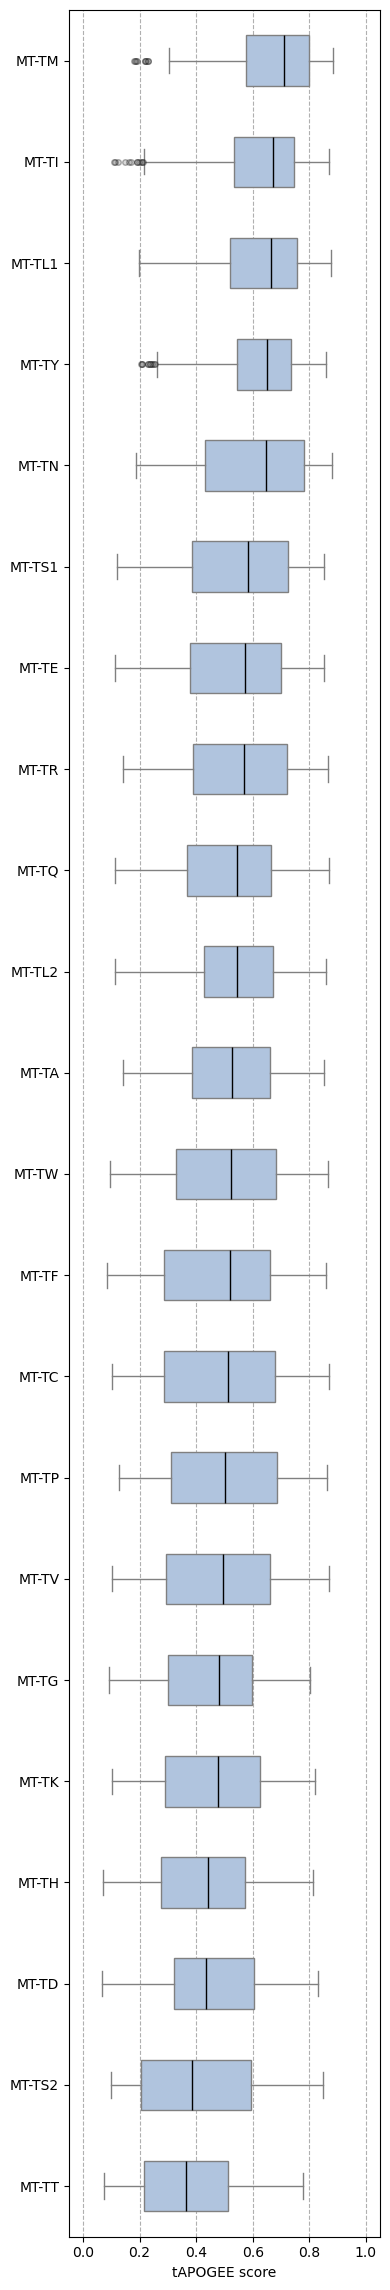

In [19]:
# Get unique genes sorted (optional for consistency)
genes = tapogee_scores.groupby("Gene_symbol").tAPOGEE_oob_score.median().sort_values(ascending=True).index
n_genes = len(genes)

# Set up figure
plt.figure(figsize=(4, 22+1))  # Adjust width based on number of genes

# Plot all boxplots in a single call (faster and cleaner)
data = [tapogee_scores.loc[mithril_df_tRNA[mithril_df_tRNA.Gene_symbol == gene].index, "tAPOGEE_oob_score"] for gene in genes]

plt.boxplot(
    data, positions=range(n_genes), patch_artist=True, vert=False, widths=.5,
    boxprops=dict(facecolor="lightsteelblue", color="gray"),
    medianprops=dict(color="black"),
    whiskerprops=dict(color="gray"),
    capprops=dict(color="gray"),
    flierprops=dict(markerfacecolor='gray', marker='o', markersize=4, linestyle='none', alpha=0.3)
)

# Format axes
plt.yticks(range(n_genes), genes)
plt.xlabel("tAPOGEE score")
plt.xlim(-.05,1.05)
plt.grid(axis="x", ls="--")
plt.tight_layout()
plt.savefig("./svg/tAPOGEE_genes_box.svg", bbox_inches='tight')
plt.show()

In [13]:
union_df = pd.concat([
    tapogee_scores[["Gene_symbol", "tAPOGEE_posterior"]].rename(columns={"tAPOGEE_posterior": "posterior"}),
    rapogee_scores[["Gene_symbol", "rAPOGEE_posterior"]].rename(columns={"rAPOGEE_posterior": "posterior"})]
)
union_df

,Gene_symbol,posterior
Mithril_id,,
MITHRIL.1728,MT-TF,9.947513e-01
MITHRIL.1729,MT-TF,9.517089e-01
MITHRIL.1730,MT-TF,9.919106e-01
MITHRIL.1731,MT-TF,3.207829e-01
MITHRIL.1732,MT-TF,7.912251e-01
...,...,...
MITHRIL.9683,MT-RNR2,4.669735e-07
MITHRIL.9684,MT-RNR2,3.505524e-06
MITHRIL.9685,MT-RNR2,2.478844e-03


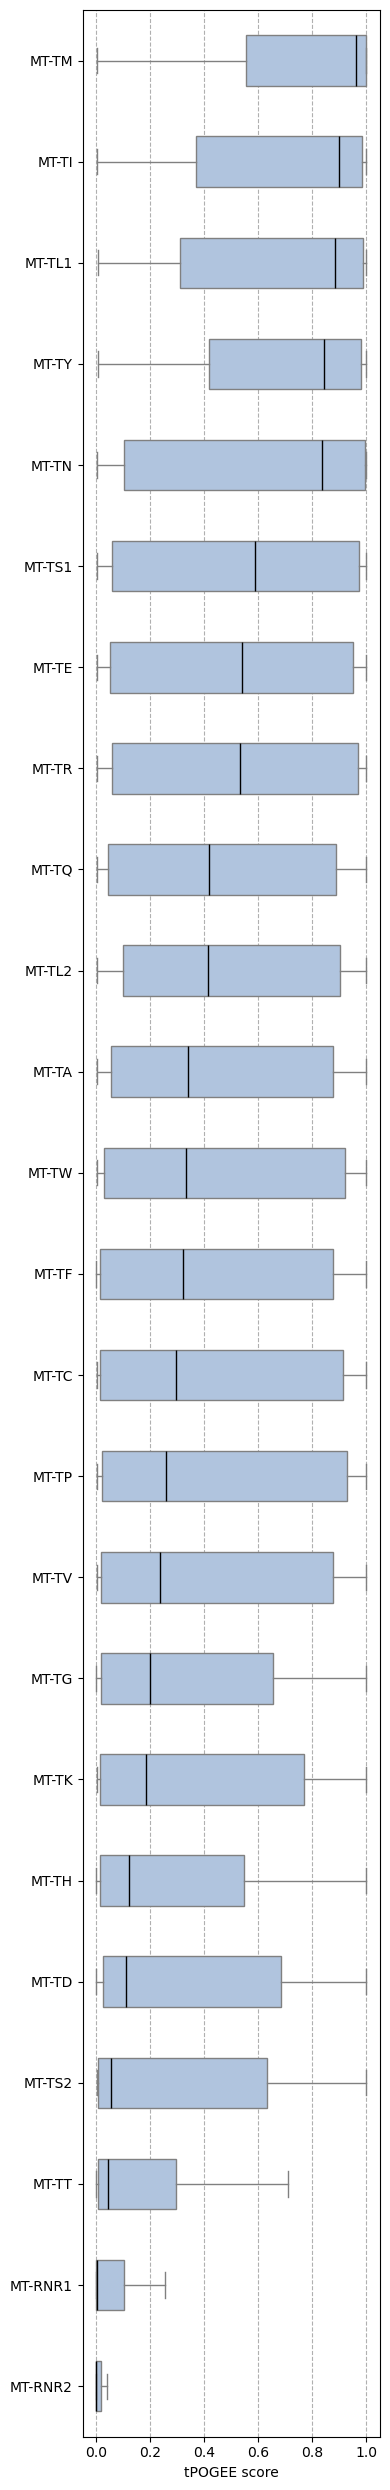

In [20]:
# Get unique genes sorted (optional for consistency)
genes = union_df.groupby("Gene_symbol").posterior.median().sort_values(ascending=True).index
n_genes = len(genes)

# Set up figure
plt.figure(figsize=(4, 24+1))  # Adjust width based on number of genes

# Plot all boxplots in a single call (faster and cleaner)
data = [union_df.loc[union_df.Gene_symbol==gene, "posterior"] for gene in genes]

plt.boxplot(
    data, positions=range(n_genes), patch_artist=True, showfliers=False, vert=False, widths=.5,
    boxprops=dict(facecolor="lightsteelblue", color="gray"),
    medianprops=dict(color="black"),
    whiskerprops=dict(color="gray"),
    capprops=dict(color="gray"),
    flierprops=dict(markerfacecolor='gray', marker='o', markersize=4, linestyle='none', alpha=0.3)
)

# Format axes
plt.yticks(range(n_genes), genes)
plt.xlabel("tPOGEE score")
plt.xlim(-.05,1.05)
plt.grid(axis="x", ls="--")
plt.tight_layout()
plt.savefig("./svg/posterior_genes_box.svg", bbox_inches='tight')
plt.show()